# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1876061
- Naam: Duain Crasto
- Datum: 06/03/2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [3]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.865469,0.962353,0.620742,1.060326,1.557373,5.985551,0.763219,3.622631,1.722187,0.972357,0.347099,0.702642,0.649668,1.308703,0.697569,"""Crime (3rd person)"""
0.750608,0.481706,0.515727,0.851599,1.048564,5.02918,0.885809,1.503489,0.32408,0.9525,0.604588,0.900434,0.941314,1.312962,0.933636,"""Romance (3rd person)"""
1.73984,1.034494,1.351793,1.004043,0.422008,5.462378,1.00469,0.582349,0.096781,1.635758,0.357265,0.209514,0.658452,0.573585,0.507984,"""Romance (1st person)"""
1.277668,0.188238,1.251281,0.907016,0.776309,1.554657,0.3489,3.443554,0.782158,0.130471,0.470524,1.233243,0.553606,0.966405,0.903978,"""Science Fiction (1st person)"""
1.225105,1.216584,1.423586,1.248953,0.965199,3.774443,0.491922,2.882402,1.151147,0.659875,0.285644,1.344977,1.0466,1.127903,0.689821,"""Fantasy (1st person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

**Antwoord:**

0. (m,n)
1. (1,n)
2. (n,n)
3. Eigenvectors: (n,n), Eigenvalues: (n,)
4. (n, n')
5. (m, n')

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [4]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)

    # TODO: PCA algoritme implementeren

    #stap 1
    gemiddelde = np.mean(arr, axis=0)
    arr_centered = arr - gemiddelde

    #stap 2
    cov_matrix = np.cov(arr_centered, rowvar=False)

    #stap 3
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    # print(np.max(eigenvalues)/np.sum(eigenvalues))

    #stap 4
    sorted_indices = np.argsort(eigenvalues)[::-1]
    best_indices = sorted_indices[:n_components]
    n_eigenvectors = eigenvectors[:, best_indices]

    print(f"n_components:{n_components} : {np.sum(eigenvalues[sorted_indices[:n_components]]) / np.sum(eigenvalues)})")
    # Stap 5.
    return arr_centered @ n_eigenvectors

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [5]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)

n_components:2 : (0.9999999999999999+0j))
[[ 0.434+0.j -0.498+0.j]
 [ 0.421+0.j  0.504+0.j]
 [-0.855+0.j -0.005+0.j]]


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

n_components:2 : 0.6866656218830466)


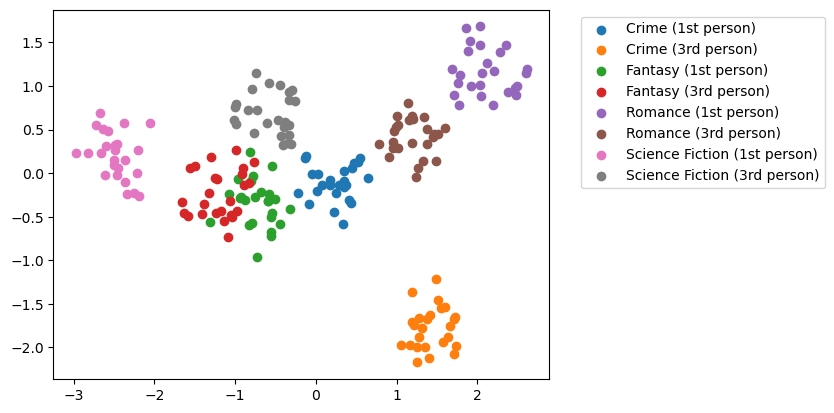

In [6]:
# TODO: Schrijf hier je code.
filtered = [col for col in data.columns if 'e_' in col]
X = data.select(filtered).to_numpy()
labels = np.array(data['label'])
X_reduced = compute_pca(X, n_components=2)
for label in np.unique(labels):
    mask = labels == label
    plt.scatter(X_reduced[mask, 0], X_reduced[mask, 1], label=label)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


n_components:3 : 0.7721763602652282)


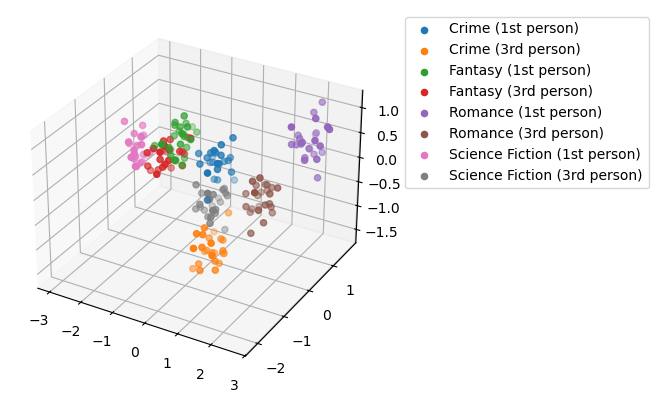

In [7]:
# TODO: Schrijf hier je code.
filtered = [col for col in data.columns if 'e_' in col]
X = data.select(filtered).to_numpy()
labels = np.array(data['label'])
X_reduced = compute_pca(X, n_components=3)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for label in np.unique(labels):
    mask = labels == label
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1], X_reduced[mask, 2], label=label)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

In [8]:
print(f"{compute_pca(X, n_components=2)}, {compute_pca(X, n_components=3)}")

n_components:2 : 0.6866656218830466)
n_components:3 : 0.7721763602652282)
[[-0.547  0.087]
 [-0.555 -0.675]
 [-0.587 -0.319]
 [-0.546 -0.457]
 [-0.551 -0.719]
 [-0.595 -0.322]
 [-1.305 -0.557]
 [-0.675 -0.221]
 [-0.76  -0.269]
 [-0.834 -0.592]
 [-0.814  0.238]
 [-0.552 -0.504]
 [-0.968 -0.068]
 [-0.507 -0.301]
 [-0.882 -0.307]
 [-0.733 -0.957]
 [-0.926 -0.269]
 [-1.077 -0.243]
 [-0.934 -0.283]
 [-0.776 -0.037]
 [-0.44  -0.58 ]
 [-0.584 -0.243]
 [-0.32  -0.407]
 [-0.803 -0.09 ]
 [-0.794 -0.572]
 [-1.633 -0.46 ]
 [-1.303  0.187]
 [-1.058 -0.317]
 [-0.984  0.269]
 [-1.32  -0.223]
 [-0.908  0.055]
 [-1.557  0.062]
 [-1.174 -0.435]
 [-1.227 -0.065]
 [-1.093 -0.735]
 [-1.255 -0.057]
 [-1.492  0.086]
 [-1.143 -0.553]
 [-0.831 -0.11 ]
 [-1.056 -0.483]
 [-1.416 -0.466]
 [-1.586 -0.495]
 [-0.893 -0.133]
 [-0.973 -0.439]
 [-0.913 -0.014]
 [-0.771  0.128]
 [-1.387 -0.349]
 [-1.653 -0.326]
 [-1.234 -0.452]
 [-1.033 -0.503]
 [-2.457 -0.018]
 [-2.501  0.146]
 [-2.825  0.23 ]
 [-2.2    0.268]
 [-2.673

In [9]:
print(f"{compute_pca(X, n_components=7)}")

n_components:7 : 0.9049017075553293)
[[-0.547  0.087  0.712 ...  0.184  0.012  0.27 ]
 [-0.555 -0.675  0.499 ...  0.547 -0.263  0.064]
 [-0.587 -0.319  0.368 ...  0.712  0.276  0.075]
 ...
 [ 1.395 -2.119 -0.605 ...  0.072  0.078 -0.522]
 [ 1.573 -1.939 -0.123 ... -0.234 -0.023 -0.164]
 [ 1.658 -1.749 -0.599 ... -0.315  0.261 -0.072]]


In [10]:
print(f"{compute_pca(X, n_components=11)}")

n_components:11 : 0.9616681690332414)
[[-0.547  0.087  0.712 ... -0.351  0.118 -0.224]
 [-0.555 -0.675  0.499 ... -0.093 -0.057  0.148]
 [-0.587 -0.319  0.368 ... -0.024  0.265  0.248]
 ...
 [ 1.395 -2.119 -0.605 ...  0.11  -0.071 -0.307]
 [ 1.573 -1.939 -0.123 ...  0.162 -0.037  0.001]
 [ 1.658 -1.749 -0.599 ... -0.022 -0.207 -0.349]]


**Antwoord:**
1. Alles behalve rood Fantasy (3rd person) en groen Fantasy (1st person).
2. 2D = 69% en 3D = 77%.
3. Je hebt 7 n_components om 90% van de informatie te bewaren.
4. Je hebt 11 n_components nodig om 95% van de informatie te bewaren.

## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

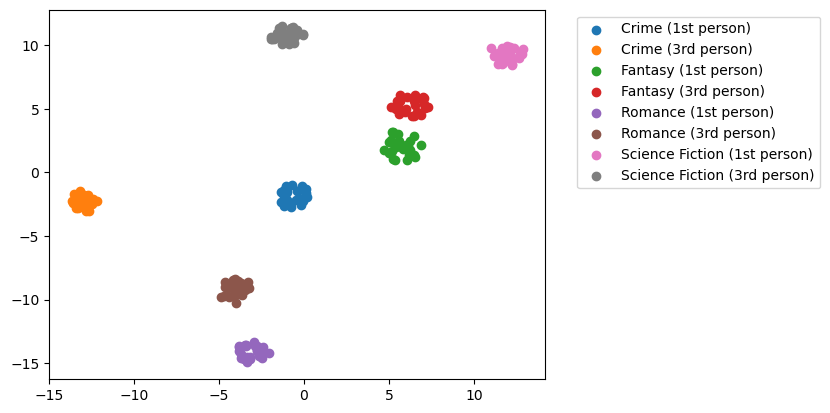

In [11]:
# TODO: Schrijf hier je code.
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)
for label in np.unique(labels):
    mask = labels == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=label)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

**Antwoord:**
1. Met t-SNe kun je alle categoriën differentiëren. Bij PCA je dit niet doen voor alle categoriën.
2. Bij PCA weet je hoeveel informatie er verloren gaat en bij t-SNE wordt de lokale verhouding tussen de datapunten behouden.

3. Ik zou t-SNE gebruiken om features bij elkaar te clusteren en ik zou PCA gebruiken als ik wil weten hoeveel informatie behouden/verloren wordt.
4. Ik zou PCU gebruiken als ik met een dataset wil kijken naar feature-importance en probeer een zo goed mogelijk en efficiënt model te maken.
5. Ik zou t-SNE gebruiken als ik bepaalde woorden die vaak voorkomen in een bepaalde context wil clusteren.

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

**Antwoord:**
1. De dimensionaliteit is erg hoog: 3840 × 2160 × 3 = 24.883.200 dimensies voor één plaatje.
2. Ik zou beiden kunnen proberen. Ik zou kunnen beginnen met PCA en de belangrijkste features kunnen kiezen en ik zou met t-SNE clusters van bepaalde soorten schade kunnen ontdekken.

# Opdracht voor Boven Niveau

Ik vroeg me af of er ook nog een mogelijkheid was om de dimensionaliteitsreductie om te keren.
Dit bleek mogelijk te zijn: door de gereduceerde data stap voor stap terug te rekenen, kun je 
een benadering van de originele data terugkrijgen (bron: https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html). Hoe meer componenten je gebruikt bij de 
reductie, hoe kleiner de fout in de reconstructie — dit is te zien in onderstaande plot.

n_components= 1  →  MSE: 0.134759
n_components= 2  →  MSE: 0.086140
n_components= 3  →  MSE: 0.062632
n_components= 4  →  MSE: 0.049750
n_components= 5  →  MSE: 0.039266
n_components= 6  →  MSE: 0.031725
n_components= 7  →  MSE: 0.026144
n_components= 8  →  MSE: 0.021568
n_components= 9  →  MSE: 0.017558
n_components=10  →  MSE: 0.013982
n_components=11  →  MSE: 0.010538
n_components=12  →  MSE: 0.007555
n_components=13  →  MSE: 0.004781
n_components=14  →  MSE: 0.002366
n_components=15  →  MSE: 0.000000


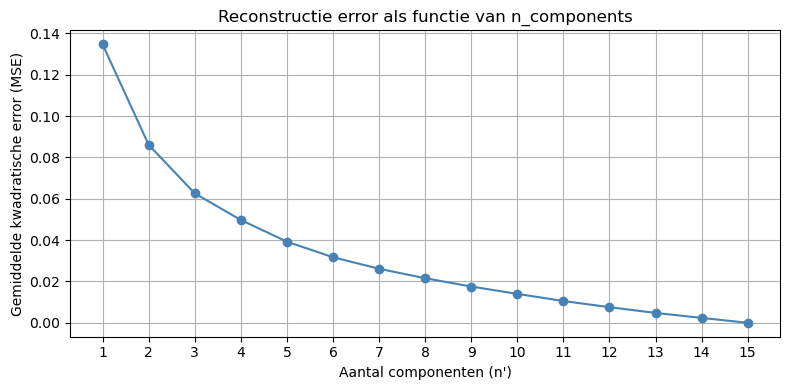

In [13]:
def compute_pca_reconstruct(X, n_components):
    arr = np.array(X, dtype=float)
    
    # Stap 1: Centreren
    mean = np.mean(arr, axis=0)
    arr_centered = arr - mean
    
    # Stap 2 & 3: Covariantiematrix + Eigenvectoren
    cov_matrix = np.cov(arr_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Stap 4: Selecteer de beste n_components eigenvectoren
    sorted_indices = np.argsort(eigenvalues)[::-1]
    selected = eigenvectors[:, sorted_indices[:n_components]]  
    
    # Stap 5: Reduceer
    X_reduced = arr_centered @ selected  
    
    # INVERSE STAP
    X_reconstructed = X_reduced @ selected.T + mean     
    
    return X_reduced, X_reconstructed


# MSE berekenen
n_range = range(1, X.shape[1] + 1)  
mse_values = []

for n in n_range:
    _, X_reconstructed = compute_pca_reconstruct(X, n_components=n)
    mse = np.mean((X - X_reconstructed) ** 2)
    mse_values.append(mse)
    print(f"n_components={n:2d}  →  MSE: {mse:.6f}")

# Plot reconstructie-error
plt.figure(figsize=(8, 4))
plt.plot(list(n_range), mse_values, marker='o', color='steelblue')
plt.xlabel("Aantal componenten (n')")
plt.ylabel("Gemiddelde kwadratische error (MSE)")
plt.title("Reconstructie error als functie van n_components")
plt.xticks(list(n_range))
plt.grid(True)
plt.tight_layout()
plt.show()

Je kunt zien dat de fout het sterkst daalt in de eerste paar componenten, van 0.13 bij 1 component naar al 0.06 bij 3 componenten. Daarna vlakt de curve steeds meer af, wat betekent dat extra componenten steeds minder nieuwe informatie toevoegen aan de reconstructie.